# 08 · Diffusion Model: Membangkitkan Skenario Masa Depan

Model kuantil memberi rentang **per hari**. Banyak pertanyaan risiko justru menyangkut **seluruh jalur**:

> *"Berapa peluang saldo turun lebih dari 5% **kapan pun** dalam 14 hari ke depan?"*
> *"Seberapa rendah titik terendah saldo pada 5% skenario terburuk?"*

Untuk itu dibutuhkan model yang membangkitkan **jalur lengkap**, yaitu model generatif. Di sini dipakai
**DDPM bersyarat** (Ho dkk., 2020; mirip TimeGrad/CSDI):

1. **Training:** jalur masa depan asli diberi noise sebanyak *k* langkah, lalu jaringan belajar menebak noise
   itu dengan syarat histori dan kalender.
2. **Sampling:** mulai dari noise murni, lalu dibersihkan 50 langkah, dan diulang 200 kali sehingga
   menghasilkan 200 skenario.

Model ini juga dilatih secara **federated**: arah riset ke-2 dan ke-3 di essay digabung menjadi satu.

Dua pelajaran teknis yang ditemukan saat membangun model ini (detail di `PROGRESS.md`):
- Tanpa **x0-clipping** saat sampling, galat menumpuk dan jalur "melayang" (CRPS memburuk 0.22 → 0.35).
- *Loss* menebak noise **tidak selaras** dengan kualitas forecast, sehingga epoch/ronde terbaik dipilih
  dengan pinball loss dari sampel.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110

In [2]:
from fedprob.data import oracle_paths
from fedprob.experiment import run_experiment_cached, method_label
from fedprob.metrics import independent_paths, path_min_metrics
from fedprob.plots import plot_fan, plot_history, plot_paths

DM = ("oracle", "fedavg", "local", "diffusion_fed", "diffusion_central", "diffusion_fed+aci")
res = {s: run_experiment_cached(s, methods=DM, cache_dir="../results", verbose=False) for s in ["normal", "data_langka"]}
pd.concat({s: r.summary()[["MAE", "CRPS", "Coverage80", "Lebar80"]] for s, r in res.items()}, axis=1).rename(index=method_label)

normal                            \
                                       MAE   CRPS Coverage80 Lebar80   
method                                                                 
Oracle (distribusi sebenarnya)       0.285  0.162      0.724   0.778   
Federated (FedAvg)                   0.353  0.203      0.681   0.908   
Local-only (tiap bank sendiri)       0.338  0.195      0.698   0.888   
Diffusion (federated)                0.334  0.190      0.695   0.868   
Diffusion (centralized)              0.338  0.197      0.636   0.791   
Diffusion (federated) + ACI adaptif  0.334  0.193      0.821   1.161   

                                    data_langka                            
                                            MAE   CRPS Coverage80 Lebar80  
method                                                                     
Oracle (distribusi sebenarnya)            0.277  0.157      0.724   0.754  
Federated (FedAvg)                        0.342  0.194      0.727   0.964  
Local-only (tiap bank sendiri)            0.340  0.210      0.796   1.265  
Diffusion (federated)                     0.334  0.190      0.692   0.859  
Diffusion (centralized)                   0.319  0.181      0.730   0.899  
Diffusion (federated) + ACI adaptif       0.334  0.192      0.815   1.152

<Axes: title={'center': 'Diffusion federated: pinball loss validasi (dari sampel) per ronde'}, xlabel='ronde / epoch', ylabel='val_loss'>

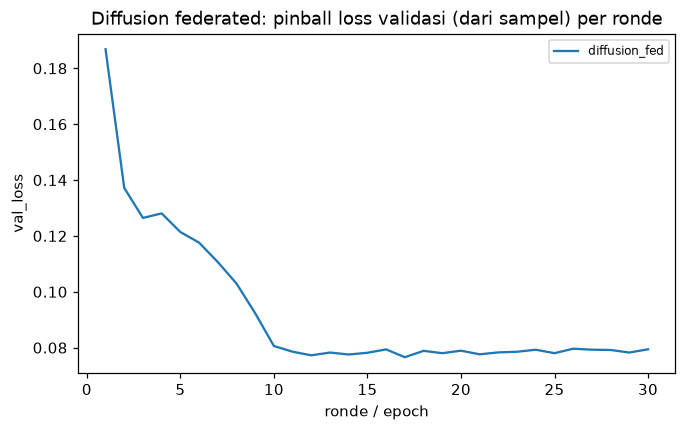

In [3]:
plot_history({k: v for k, v in res["normal"].histories.items() if k in ("diffusion_fed",)},
             title="Diffusion federated: pinball loss validasi (dari sampel) per ronde")

## Skenario masa depan dari satu titik waktu

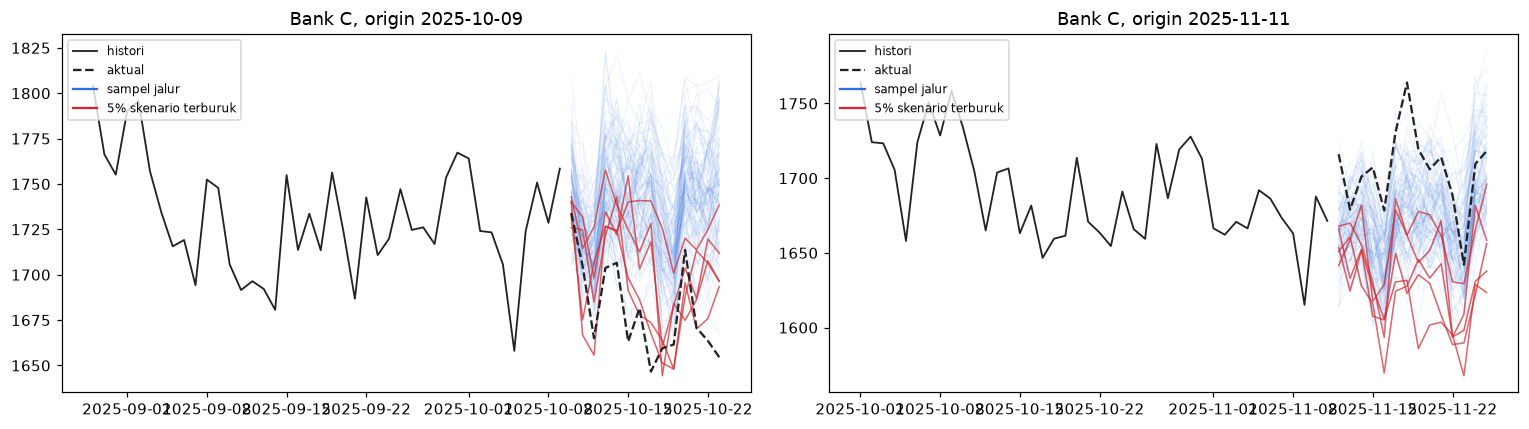

In [4]:
r = res["normal"]; k = 2; c = r.clients[k]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, oi in zip(axes, [7, 40]):
    o = int(c.test.origins[oi])
    plot_paths(r.sim, k, o, c.denorm(r.extras["diffusion_fed_paths"][k][oi]), ax=ax,
               title=f"{c.name}, origin {r.sim.dates[o].date()}")
plt.tight_layout()

Setiap garis biru adalah satu skenario yang mungkin. Garis merah adalah **5% skenario terburuk** menurut
titik terendahnya, bahan untuk *stress testing*. Pola mingguan tetap terlihat di setiap jalur karena model
mempelajari struktur jalur, bukan hanya rentang per hari.

## Mengapa jalur bersama penting?
Pembanding: membangkitkan jalur dari model kuantil (FedAvg) dengan **menarik tiap hari secara independen**.
Distribusi per harinya sama, tetapi keterkaitan antar hari hilang.

In [5]:
rows = []
for s, r in res.items():
    for c in r.clients:
        last = c.test.x_hist[:, -1]
        orc = np.stack([(oracle_paths(r.sim, c.bank, int(o), 14, 500, seed=int(o)) - c.center) / c.scale for o in c.test.origins])
        for name, S in [("Oracle", orc),
                        ("Diffusion (federated)", r.extras["diffusion_fed_paths"][c.bank]),
                        ("Diffusion (centralized)", r.extras["diffusion_central_paths"][c.bank]),
                        ("FedAvg kuantil, hari independen", independent_paths(r.preds["fedavg"][c.bank]))]:
            rows.append({"skenario": s, "metode": name, **path_min_metrics(S, c.test.y, last)})
path_tab = pd.DataFrame(rows).groupby(["skenario", "metode"], sort=False).mean()
path_tab

CRPS_min  Coverage80_min  \
skenario    metode                                                      
normal      Oracle                              0.153           0.760   
            Diffusion (federated)               0.202           0.685   
            Diffusion (centralized)             0.189           0.692   
            FedAvg kuantil, hari independen     0.210           0.481   
data_langka Oracle                              0.149           0.760   
            Diffusion (federated)               0.200           0.698   
            Diffusion (centralized)             0.172           0.789   
            FedAvg kuantil, hari independen     0.211           0.494   

                                             Brier_turun  P_turun_pred  \
skenario    metode                                                       
normal      Oracle                                 0.099         0.166   
            Diffusion (federated)                  0.118         0.100   
            Diffusion (centralized)                0.114         0.132   
            FedAvg kuantil, hari independen        0.109         0.145   
data_langka Oracle                                 0.090         0.148   
            Diffusion (federated)                  0.112         0.087   
            Diffusion (centralized)                0.097         0.144   
            FedAvg kuantil, hari independen        0.100         0.163   

                                             Frek_turun_aktual  
skenario    metode                                              
normal      Oracle                                       0.200  
            Diffusion (federated)                        0.200  
            Diffusion (centralized)                      0.200  
            FedAvg kuantil, hari independen              0.200  
data_langka Oracle                                       0.175  
            Diffusion (federated)                        0.175  
            Diffusion (centralized)                      0.175  
            FedAvg kuantil, hari independen              0.175

**Cara membaca:**
- **Coverage80_min**: seberapa sering titik terendah aktual jatuh dalam interval 80% prediksi (ideal ≈ Oracle).
  Pendekatan "hari independen" jauh di bawah target karena mengabaikan bahwa hari-hari yang berdekatan saling
  terkait.
- **Brier_turun** & **P_turun_pred** vs **Frek_turun_aktual**: kualitas peluang "turun > 5%". Bandingkan
  peluang rata-rata yang diprediksi dengan frekuensi aktual: apakah model meremehkan risiko?

## Skenario stres pada bank dengan data langka

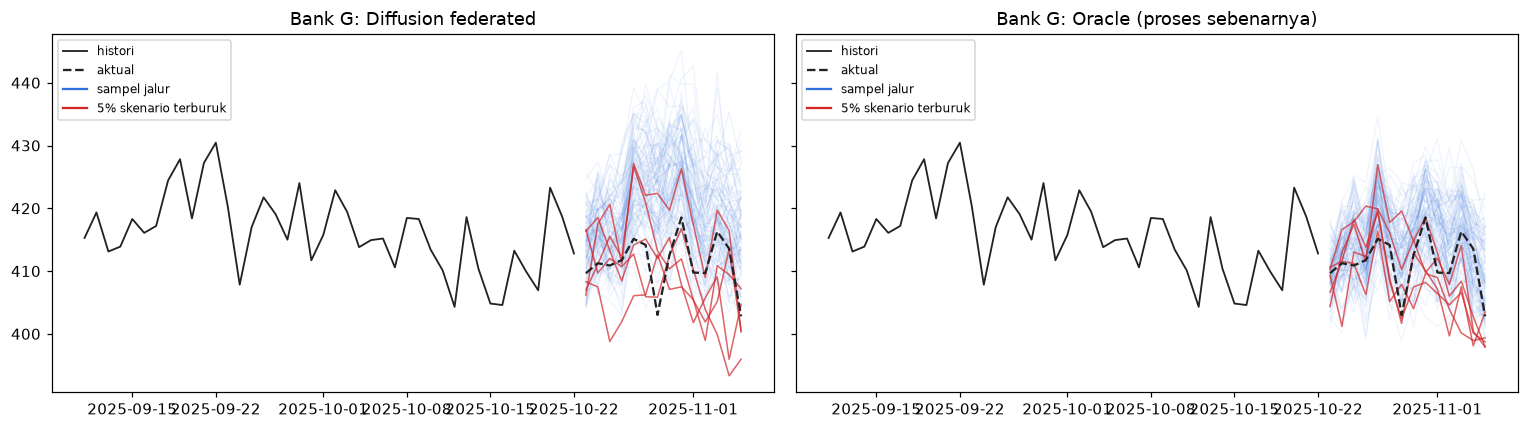

In [6]:
r = res["data_langka"]; k = 6; c = r.clients[k]; oi = 20; o = int(c.test.origins[oi])
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
plot_paths(r.sim, k, o, c.denorm(r.extras["diffusion_fed_paths"][k][oi]), ax=axes[0], title=f"{c.name}: Diffusion federated")
orc = oracle_paths(r.sim, k, o, 14, 100, seed=o)
plot_paths(r.sim, k, o, orc, ax=axes[1], title=f"{c.name}: Oracle (proses sebenarnya)")
plt.tight_layout()

## Kesimpulan
- Forecast per hari: diffusion federated mencapai CRPS **0.190** pada `normal` (FedAvg 0.203, Local 0.195), dan
  diffusion centralized **0.181** pada `data_langka`. Diffusion sekaligus memberi **jalur skenario lengkap**
  yang tidak bisa diberikan model kuantil.
- Pertanyaan tingkat jalur (titik terendah 14 hari): coverage 80% jalur diffusion **69–79%**, sedangkan jalur
  "hari independen" hanya **48–49%** (Oracle 76%).
- **Batasan jujur:** diffusion **federated** meremehkan peluang "turun > 5%" (memprediksi 9–10%, aktual 18–20%),
  sedangkan versi centralized lebih baik (13–14%). Ekor distribusi masih menjadi titik lemah, dan federasi
  memperberatnya. Model juga tidak pernah melihat shock, sehingga skenario terburuknya belum mencakup
  krisis yang belum pernah terjadi. Arah lanjutannya adalah *conditional generation* dengan variabel stres
  eksplisit dan data historis krisis.